# 1. Setup

In [1]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 2. Carregando o Dataset e inspeções iniciais

In [2]:
data = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')
# data = pd.read_csv('data.csv', index_col=0)

data = data.dropna(how='all',axis='columns')

data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 3. Preparando a estrutura dos dados

In [3]:
x = data.drop(columns=['diagnosis'])
y = data['diagnosis']

x.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# 4. Inspeções finais dos dados

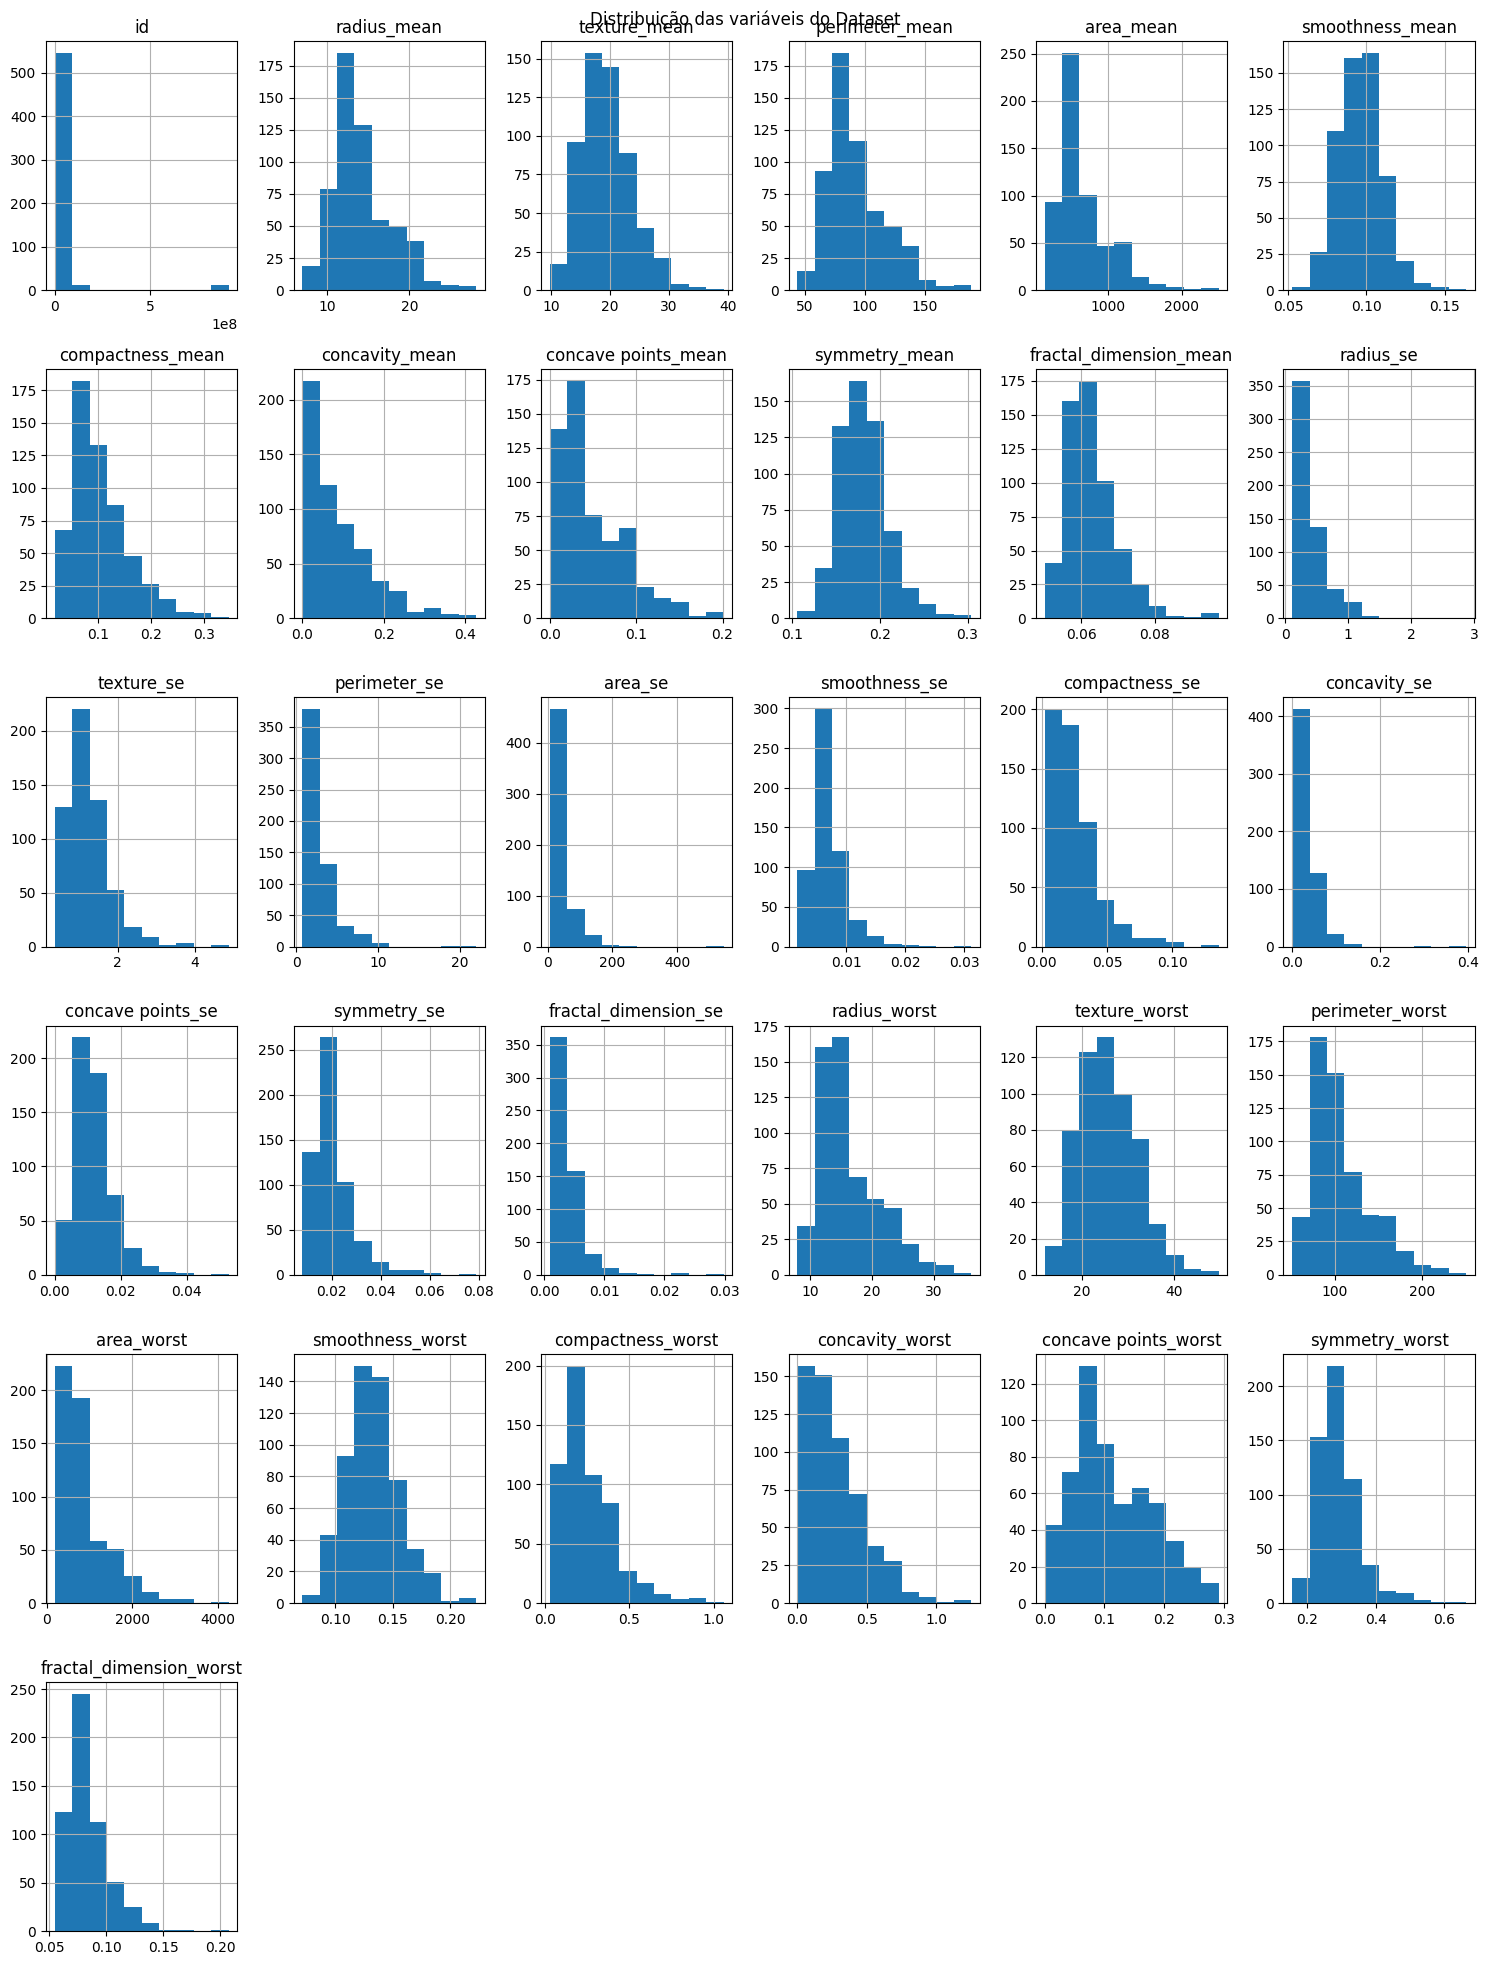

In [4]:
x[x.columns].hist(figsize=(15, 20))
plt.suptitle("Distribuição das variáveis do Dataset")
plt.tight_layout()
plt.show()

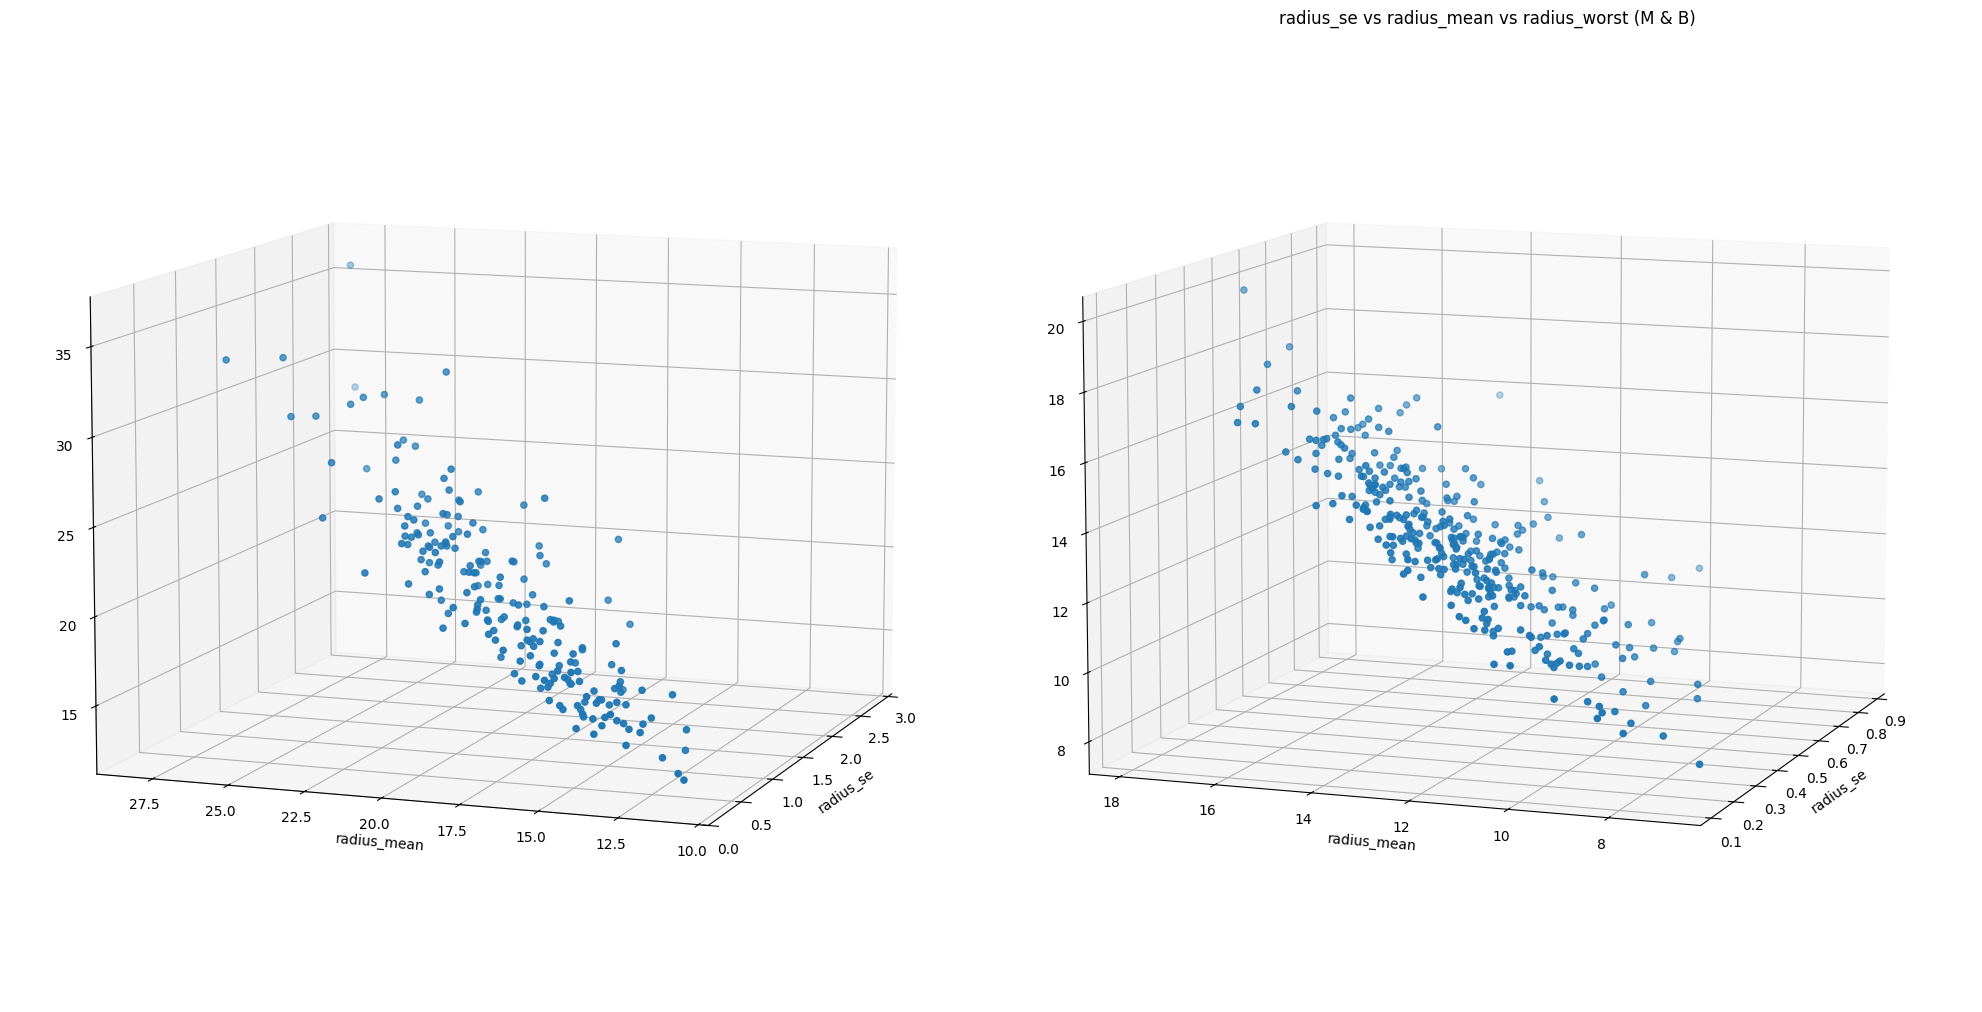

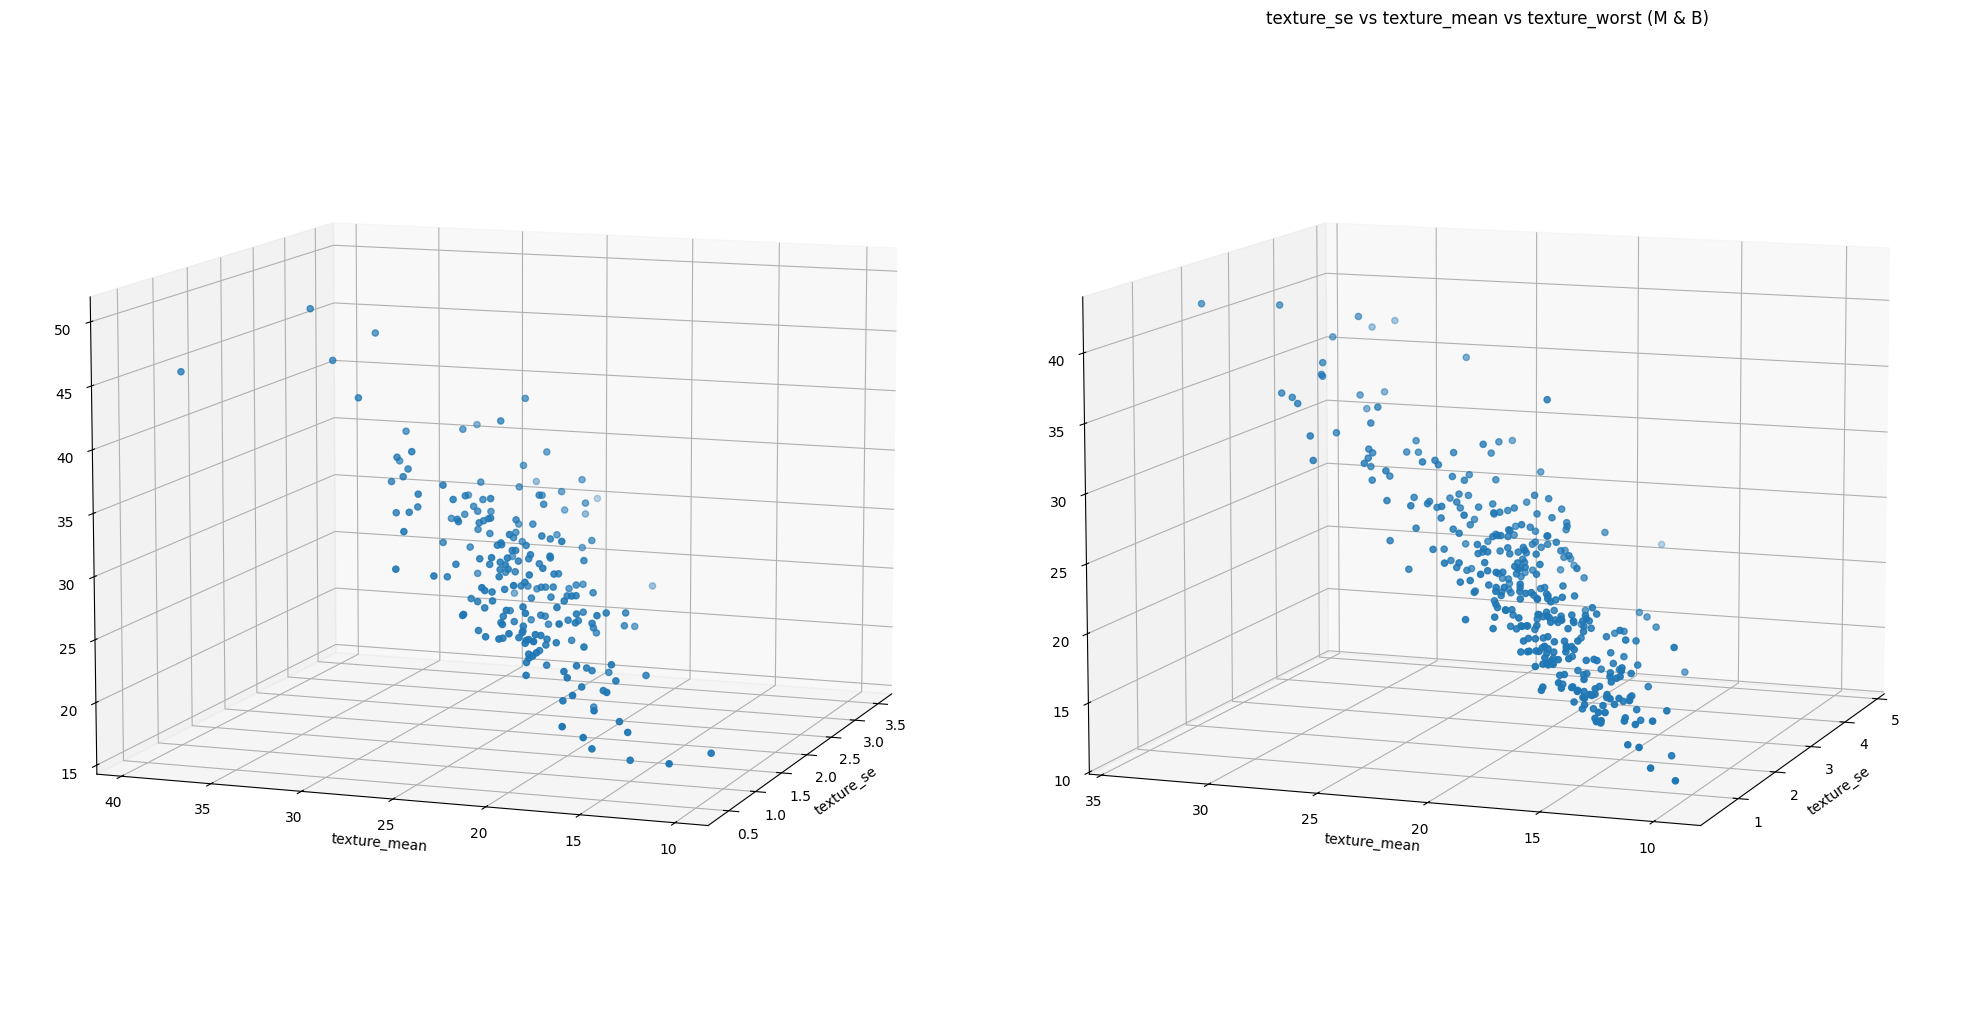

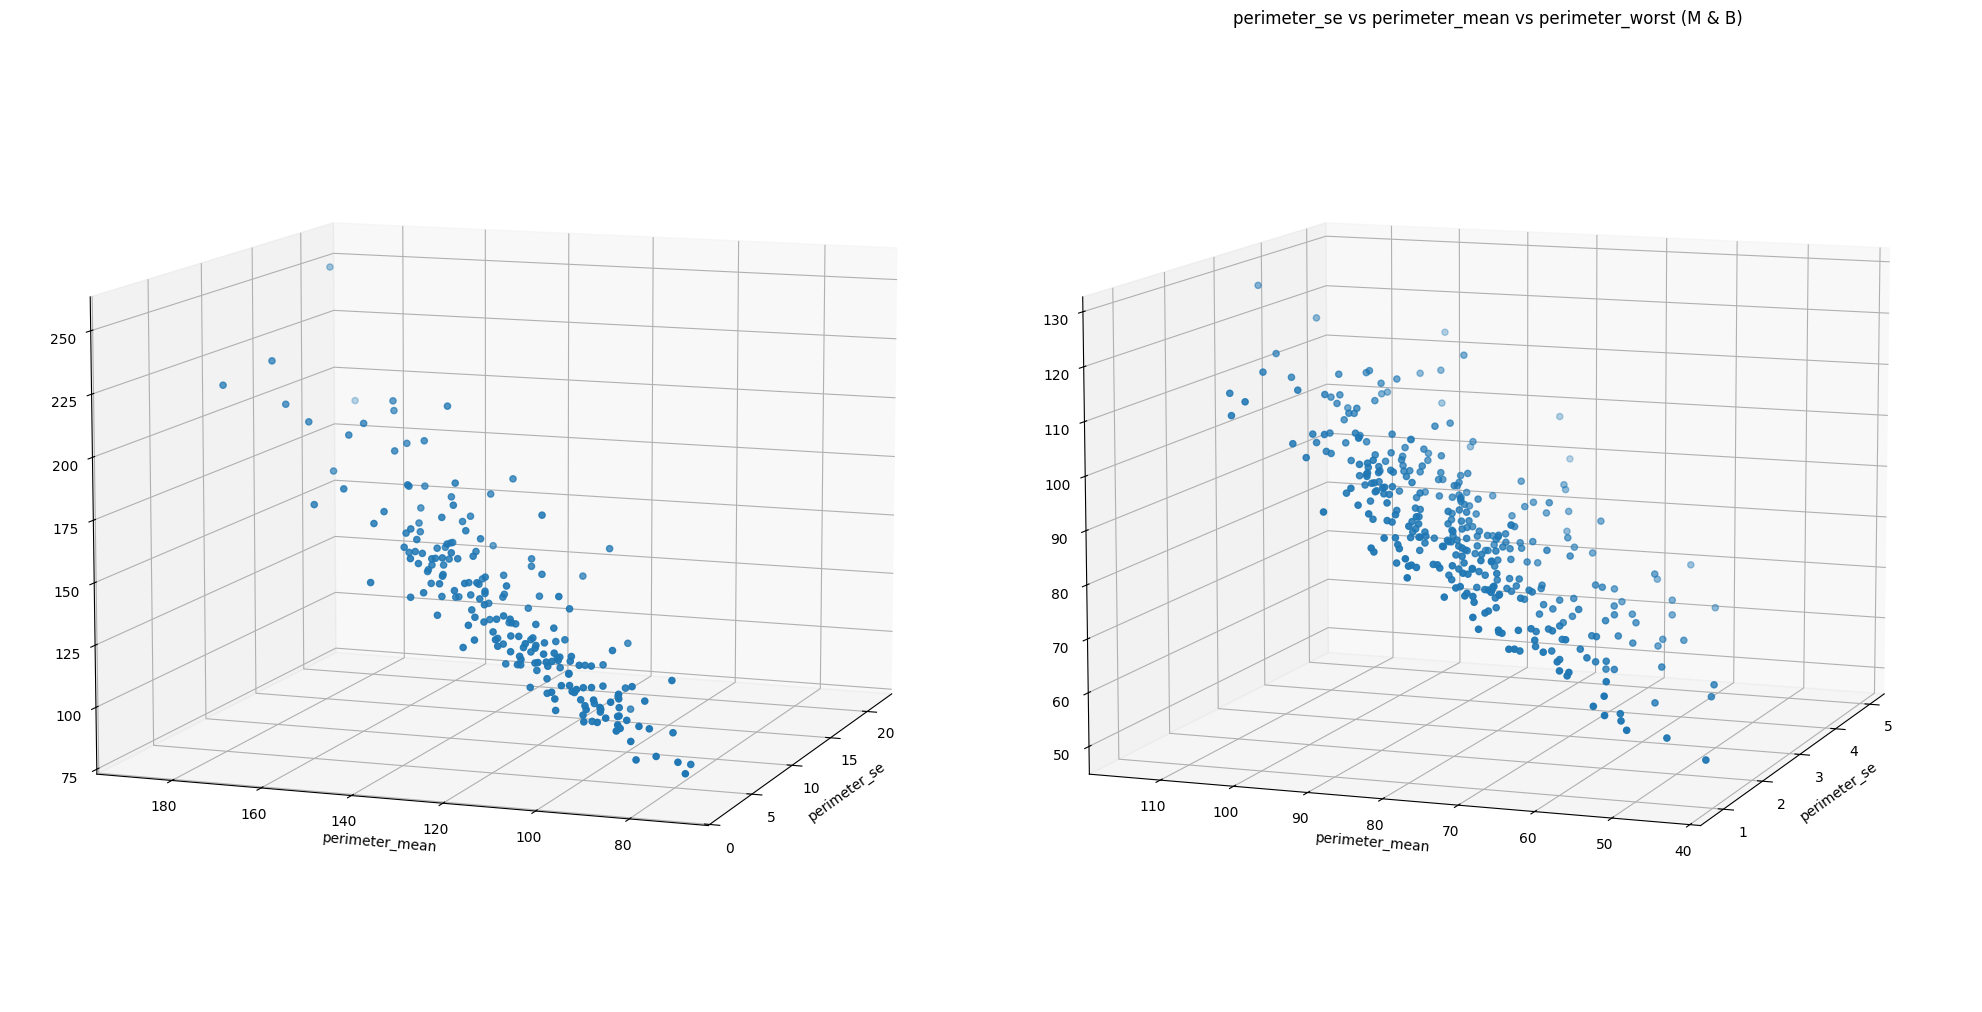

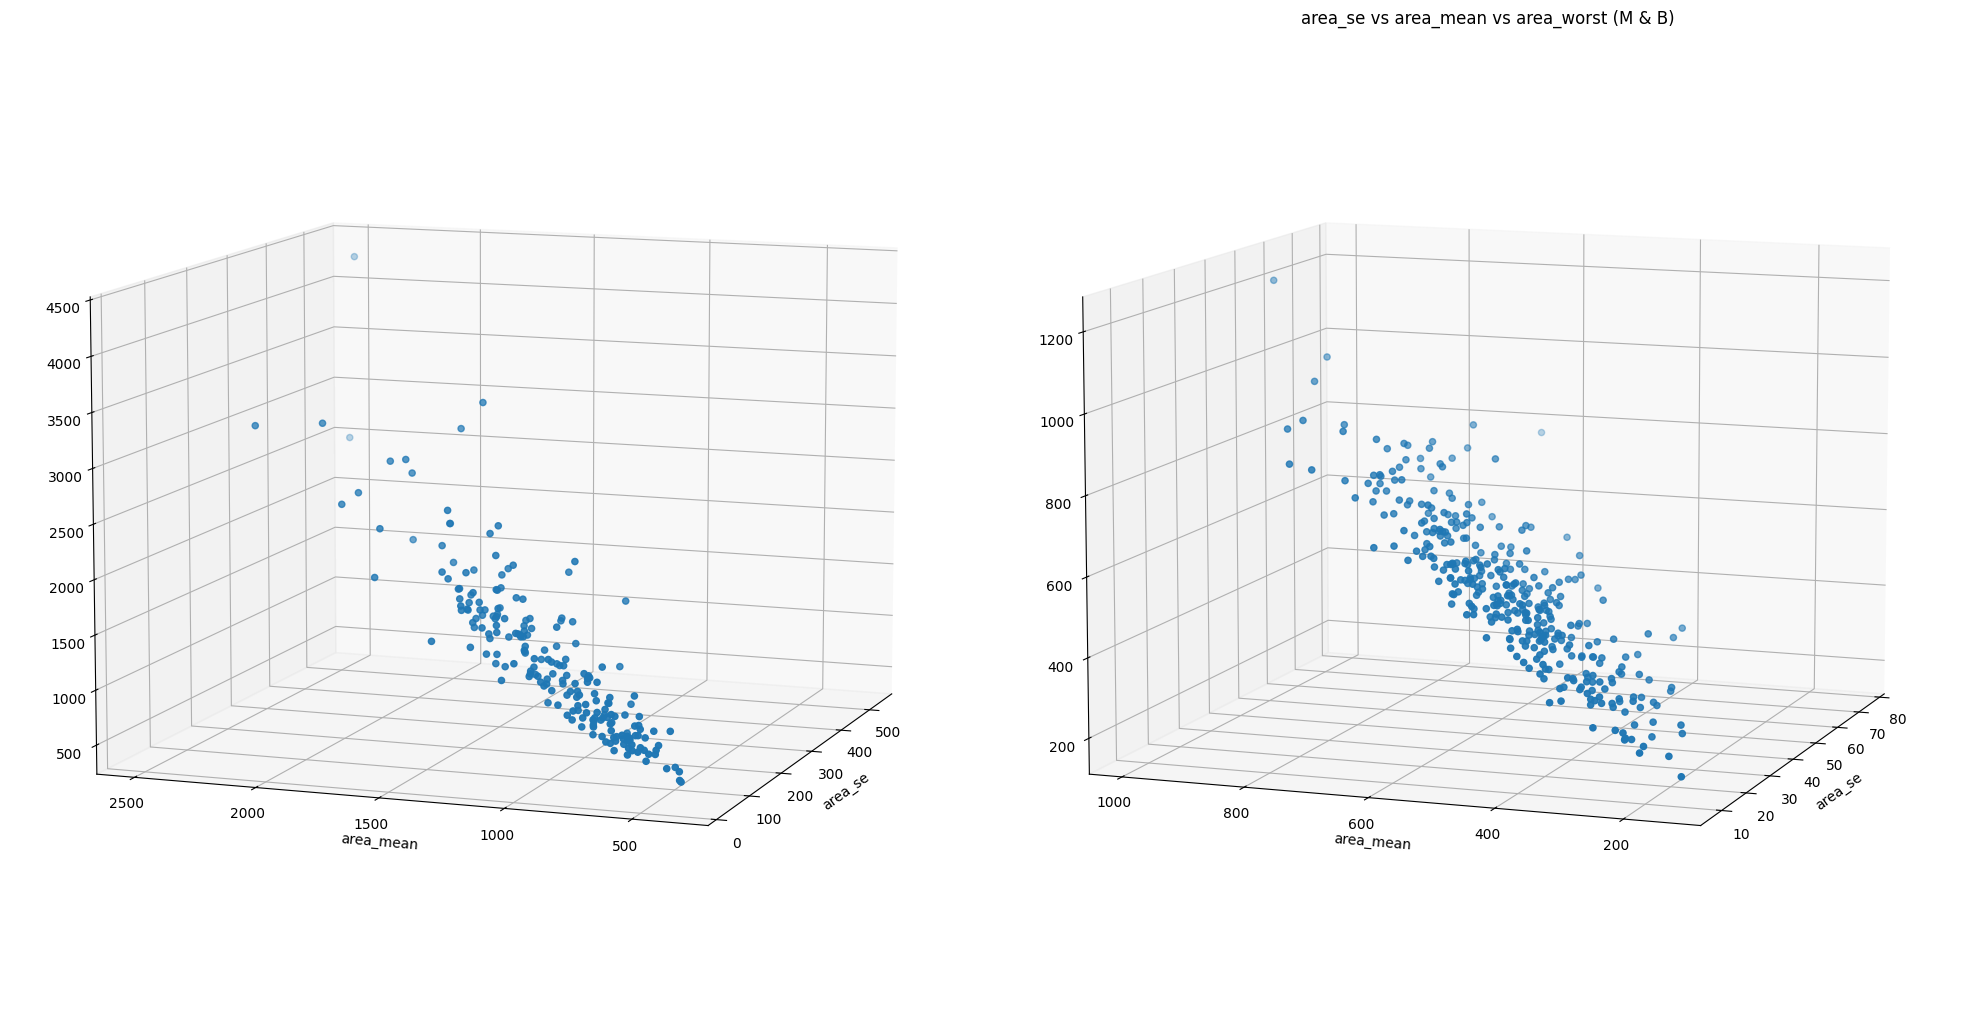

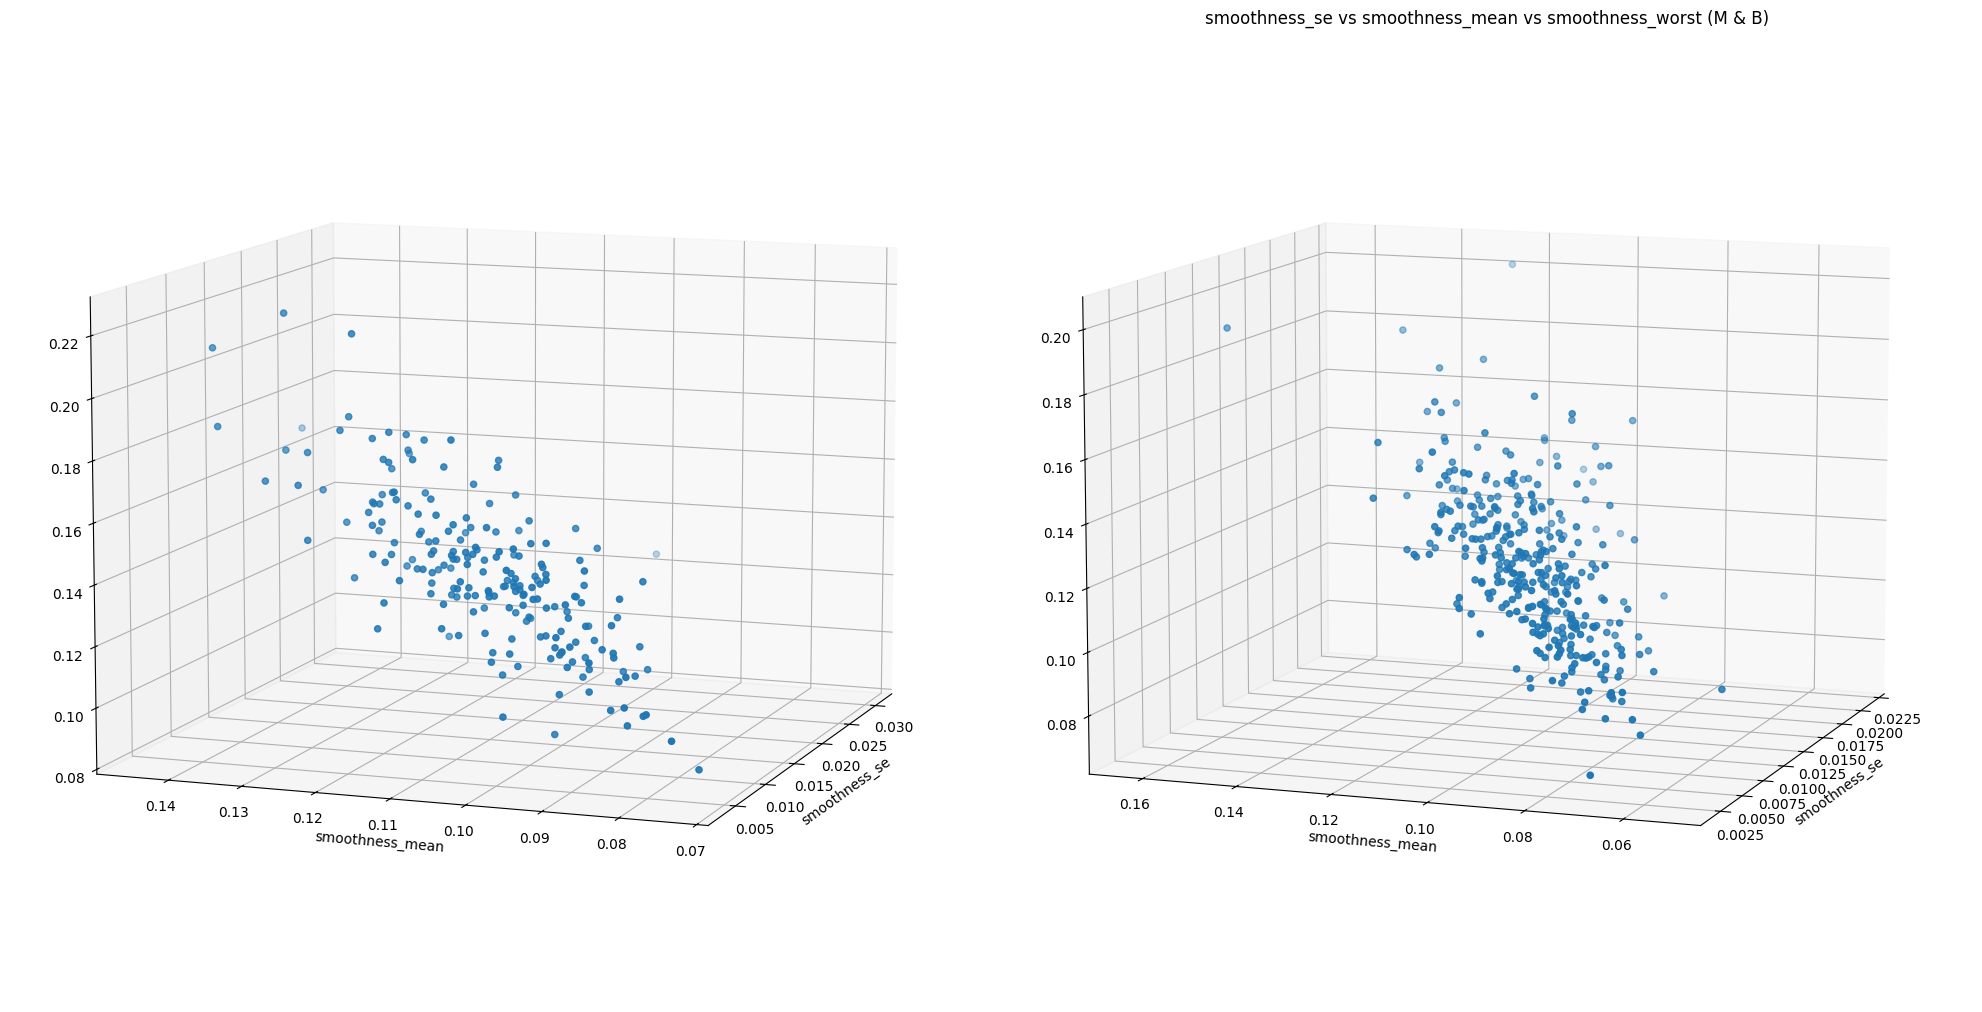

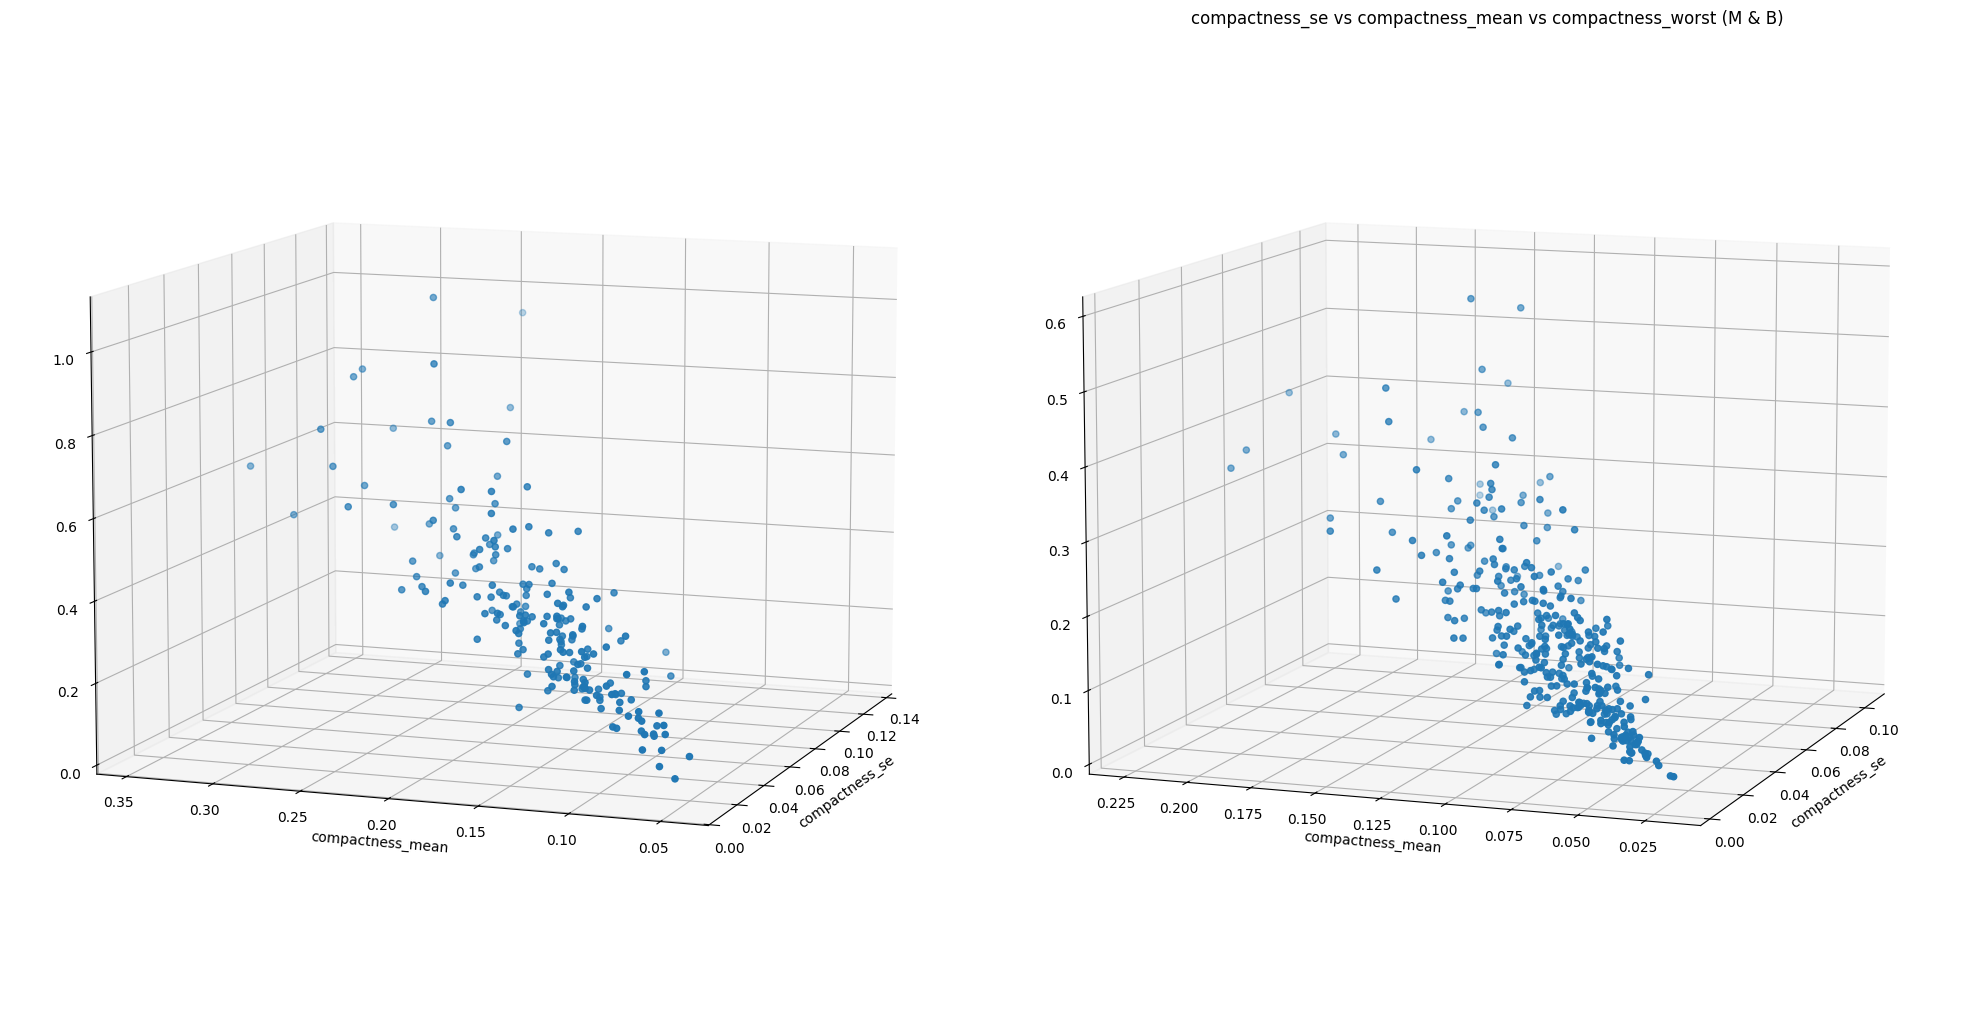

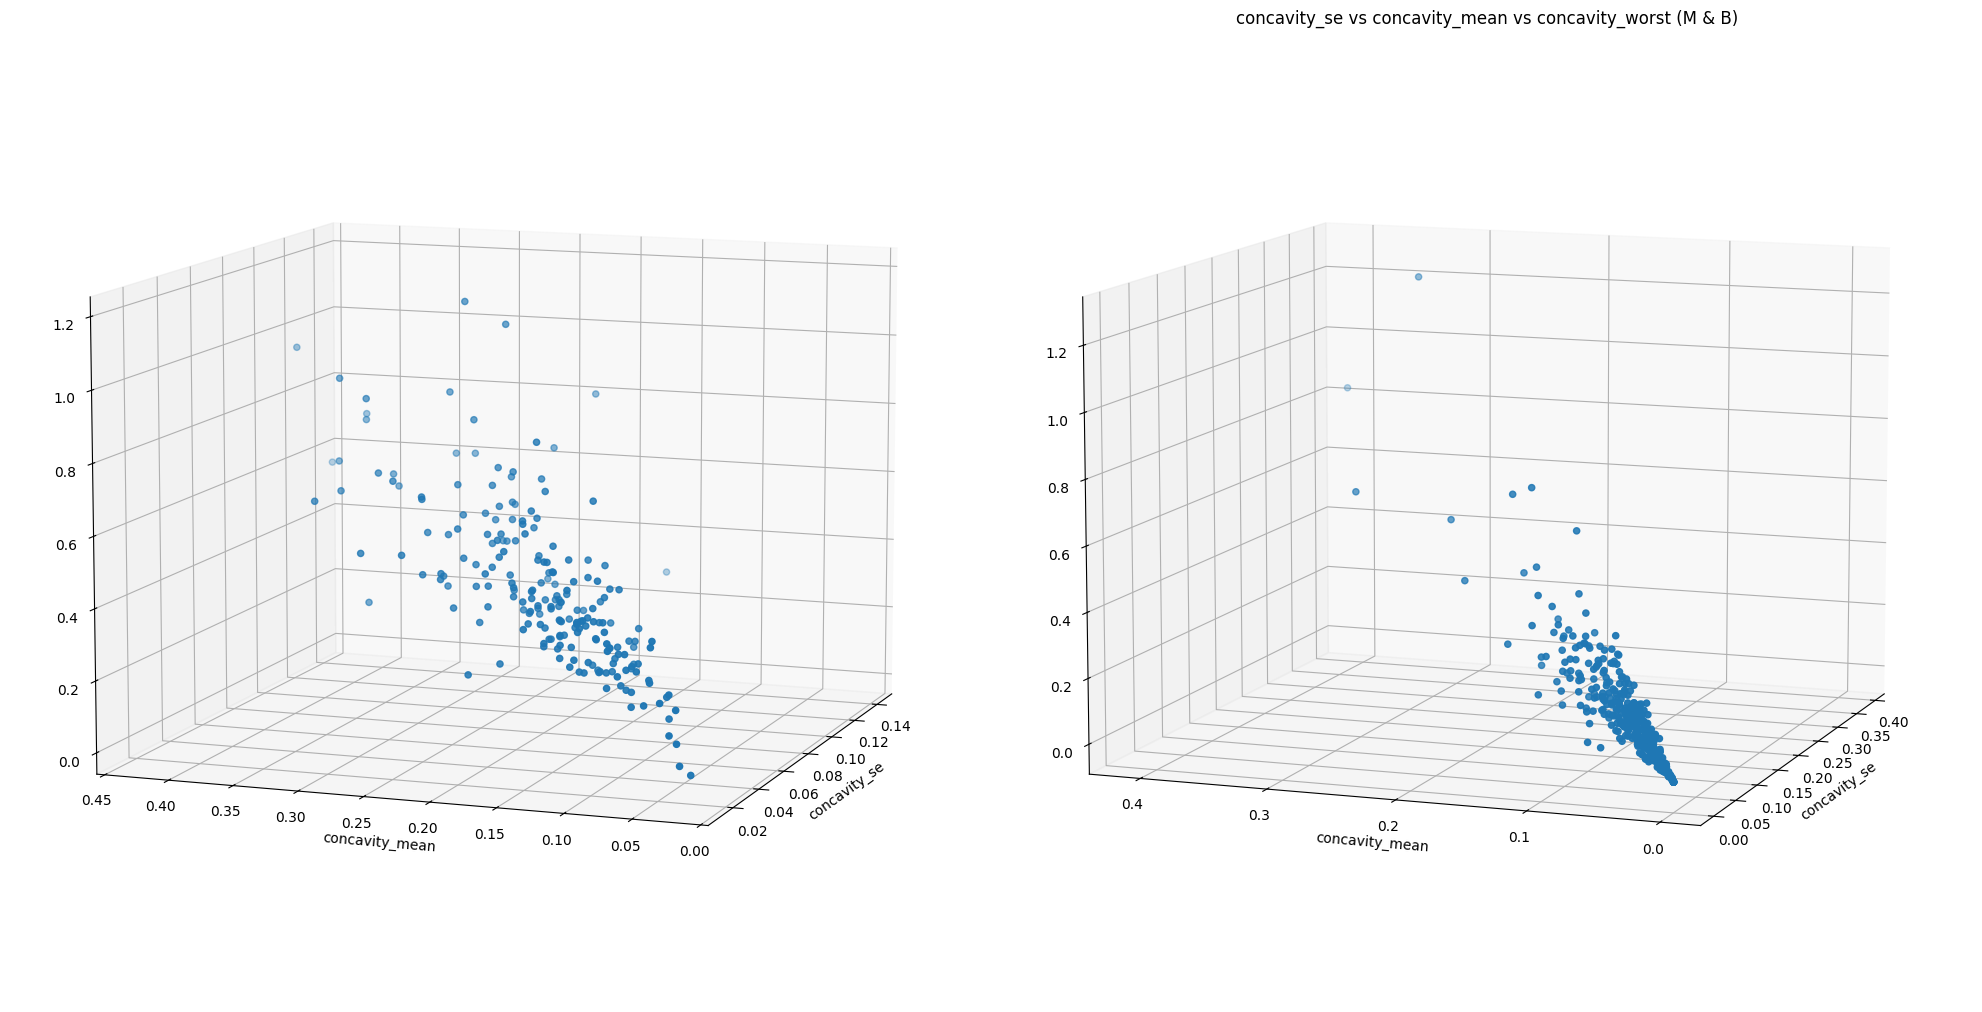

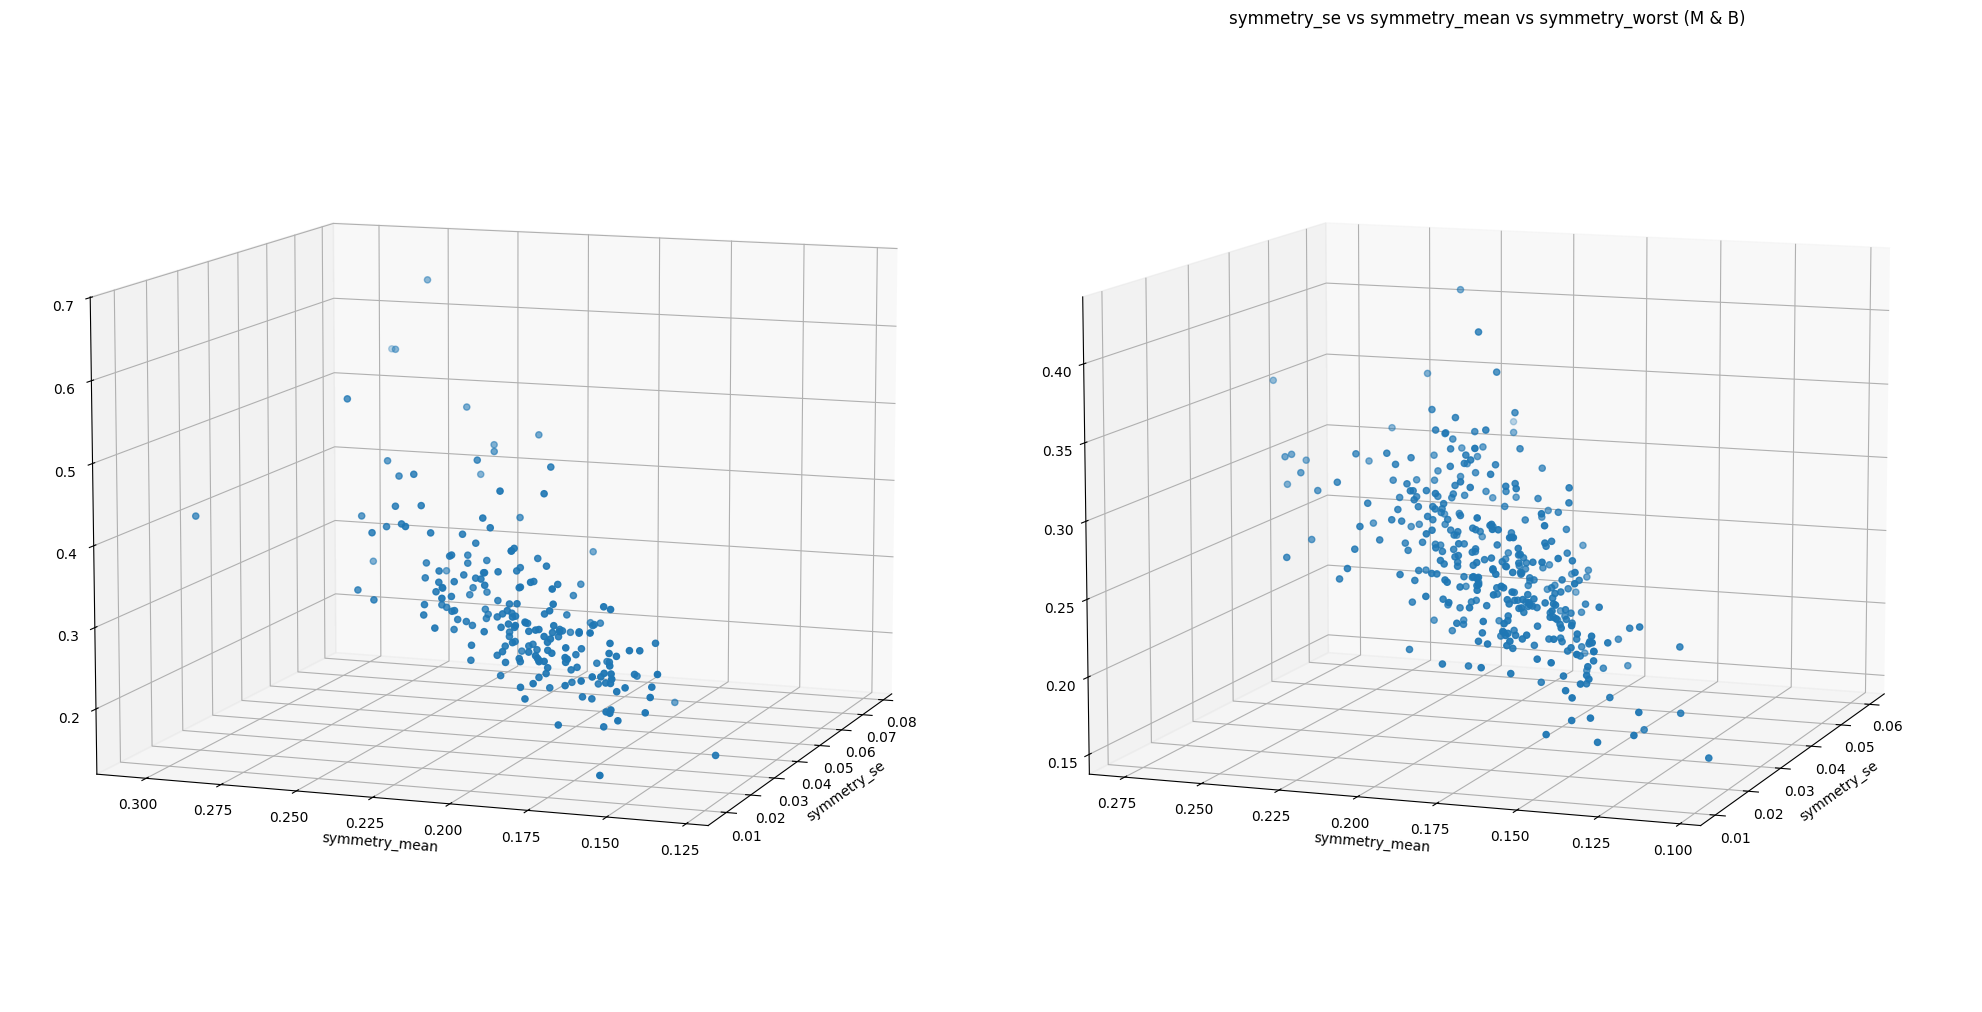

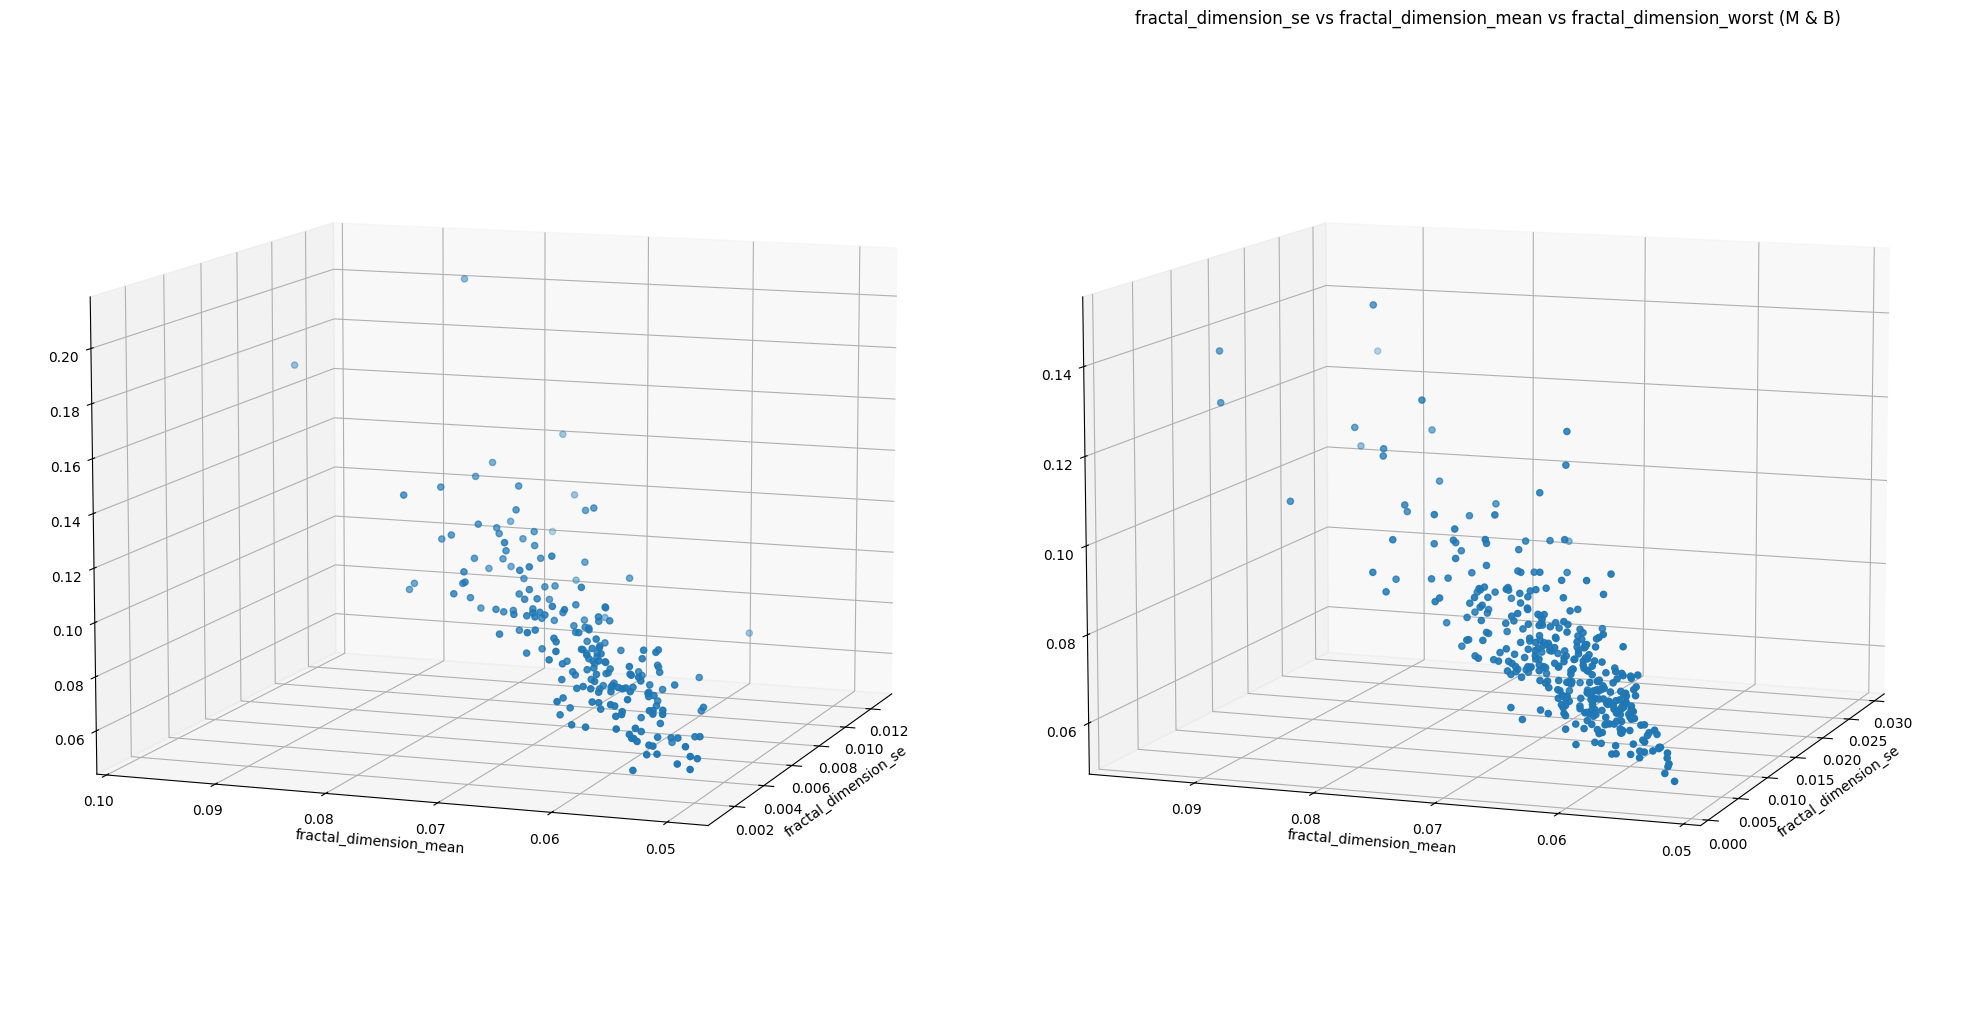

In [5]:
pairs: list[tuple[str, str]] = [
    ('radius_se', 'radius_mean', 'radius_worst'),
    ('texture_se', 'texture_mean', 'texture_worst'),
    ('perimeter_se', 'perimeter_mean', 'perimeter_worst'),
    ('area_se', 'area_mean', 'area_worst'),
    ('smoothness_se', 'smoothness_mean', 'smoothness_worst'),
    ('compactness_se', 'compactness_mean', 'compactness_worst'),
    ('concavity_se', 'concavity_mean', 'concavity_worst'),
    ('symmetry_se', 'symmetry_mean', 'symmetry_worst'),
    ('fractal_dimension_se', 'fractal_dimension_mean', 'fractal_dimension_worst'),
]

for x_col, y_col, z_col in pairs:
    figure, axis = plt.subplots(1, 2, subplot_kw={'projection': '3d'})
    figure.set_figheight(10)
    figure.set_figwidth(20)
    plt.title(f"{x_col} vs {y_col} vs {z_col} (M & B)")

    subset1 = data[data['diagnosis'] == 'M']
    subset2 = data[data['diagnosis'] == 'B']
    axis[0].set_xlabel(x_col)
    axis[1].set_xlabel(x_col)
    axis[0].set_ylabel(y_col)
    axis[1].set_ylabel(y_col)
    axis[0].scatter(subset1[x_col], subset1[y_col], subset1[z_col])
    axis[1].scatter(subset2[x_col], subset2[y_col], subset2[z_col])

    axis[0].view_init(elev=10, azim=200, roll=0)
    axis[1].view_init(elev=10, azim=200, roll=0)

    plt.tight_layout()
    plt.show()

# 5. Divisão de amostras de treino e teste

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
print('Formato de x:', x.shape)
print('Formato de y:', y.shape)

print("\nx_train:", x_train.shape)
print("x_test :", x_test.shape)

print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

Formato de x: (569, 31)
Formato de y: (569,)

x_train: (455, 31)
x_test : (114, 31)

Distribuição em y_train:
diagnosis
B    285
M    170
Name: count, dtype: int64

Distribuição em y_test:
diagnosis
B    72
M    42
Name: count, dtype: int64


# 6. Pré-processamento dos dados

In [8]:
pipeline_svm: Pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ('svm', SVC(kernel='linear', C=0.1, gamma='scale', random_state=42))
])

# 7. Treinamento do modelo

In [9]:
pipeline_svm.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=0.1, kernel='linear', random_state=42))])

# 8. Previsão da variável-alvo

In [10]:
y_pred = pipeline_svm.predict(x_test)

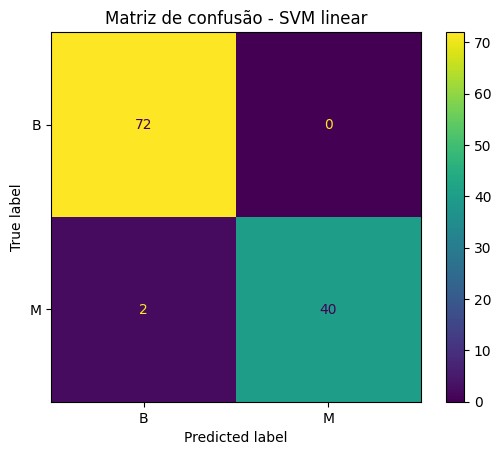

In [11]:
confusion_matrix = confusion_matrix(y_test, y_pred, labels=['B', 'M'])
disp: ConfusionMatrixDisplay = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=['B', 'M'])
disp.plot()
plt.title('Matriz de confusão - SVM linear')
plt.show()

# 9. Validação cruzada

In [12]:
scores = cross_val_score(pipeline_svm, x, y, cv=5)

print("Acurácia em cada fold:", scores)
print(f"Média: {scores.mean():.4f}")
print(f"Desvio-padrão: {scores.std():.4f}")

acc_linear = accuracy_score(y_test, y_pred)
print(f"Acurácia do SVM linear: {acc_linear:.4f}")

print("\nRelatório de classificação — SVM linear")
print(classification_report(y_test, y_pred))

Acurácia em cada fold: [0.97368421 0.97368421 0.98245614 0.96491228 0.98230088]
Média: 0.9754
Desvio-padrão: 0.0065
Acurácia do SVM linear: 0.9825

Relatório de classificação — SVM linear
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

